# SVM — classificação dos estados do jogo da velha

Uma **SVM (Support Vector Machine, ou Máquina de Vetores de Suporte)** é um
classificador supervisionado: aprende com tabuleiros e seus rótulos para prever
**Tem jogo**, **Jogador X venceu**, **Jogador O venceu** ou **Empate**.
Ela verifica o estado do jogo; não escolhe jogadas.

Usamos os mesmos CSVs e métricas dos notebooks de [k-NN](../knn/knn.ipynb),
[árvore](../arvoreDecisao/arvore_decisao.ipynb) e [MLP](../mlp/mlp.ipynb).
O procedimento experimental é: carregar dados → padronizar → ajustar parâmetros pela validação →
avaliar no teste → documentar resultados e custo.

Execute as células na ordem. A última etapa exporta os resultados e o modelo em
`svm/resultados/`. As explicações servem também como apoio para o relatório e a apresentação.

## 1. Importar as bibliotecas

`pandas` organiza tabelas; `SVC` implementa a classificação por SVM; `StandardScaler`
padroniza as entradas e `Pipeline` mantém essa transformação junto do classificador.
As métricas e os gráficos mostram acertos e erros. `time` mede custo, `warnings`
registra problemas de convergência e `joblib` salva o modelo treinado.

In [1]:
import hashlib
import json
import platform
import time
import warnings
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    f1_score, precision_score, recall_score,
)
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

## 2. Definir caminhos e classes

Mantemos as mesmas quatro classes e procuramos a raiz do projeto para permitir execução
tanto a partir da raiz quanto da pasta deste notebook. Registramos as versões utilizadas.

Os dados foram selecionados e divididos com semente 42. Neste SVM, `probability=False`:
o ajuste do `SVC` é determinístico para as mesmas entradas, ordem e ambiente, e não
precisa de `random_state`. A calibração de probabilidades, que introduziria um procedimento
adicional, não será usada neste experimento.

In [2]:
SEED = 42
CLASSES = ["Tem jogo", "Jogador X venceu", "Jogador O venceu", "Empate"]
abordagens = {
    "abordagem_1": "A1 (tabuleiro)",
    "abordagem_2": "A2 (características)",
}

RAIZ = next(
    (pasta for pasta in [Path.cwd(), *Path.cwd().parents]
     if (pasta / "dataset/processado/abordagem_1/treino.csv").is_file()),
    None,
)
if RAIZ is None:
    raise FileNotFoundError("Abra o notebook dentro da pasta deste projeto.")
BASE = RAIZ / "dataset/processado"
PASTA_RESULTADOS = BASE / "svm/resultados"
figuras = {}

versoes = {
    "python": platform.python_version(), "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__, "matplotlib": matplotlib.__version__,
    "numpy": np.__version__, "joblib": joblib.__version__,
}
print("Pasta dos dados:", BASE)
print("Versões:", versoes)

Pasta dos dados: /Users/amandacwilmsen/Desktop/tic tac toe/ai-tic-tac-toe/dataset/processado
Versões: {'python': '3.13.13', 'pandas': '3.0.5', 'scikit_learn': '1.9.0', 'matplotlib': '3.11.2', 'numpy': '2.5.2', 'joblib': '1.5.3'}


## 3. Carregar as duas abordagens

`X` contém as entradas e `y` contém a resposta correta, chamada de **rótulo**.
Removemos `estado` de `X` para não entregar a resposta ao classificador, e removemos
`id_tabuleiro`, que serve somente para identificar os exemplos.

A abordagem 1 tem nove casas numéricas (`vazio=0`, `X=1`, `O=-1`). A abordagem 2 tem
15 características: contagens de X/O, nove indicadores de ocupação, alinhamentos com
duas marcas de cada jogador, casas vazias e próximo turno hipotético.
Os CSVs já estão tratados; não geramos outros dados nem alteramos suas divisões.

In [3]:
dados = {}
arquivos_entrada = []
for ab in abordagens:
    d = {}
    for conjunto, sufixo in [("treino", "train"), ("validacao", "val"), ("teste", "test")]:
        caminho = BASE / ab / f"{conjunto}.csv"
        arquivos_entrada.append(caminho)
        df = pd.read_csv(caminho)
        assert not df.isna().any().any(), f"Valor ausente em {caminho}"
        assert set(df["estado"]) == set(CLASSES), f"Classes inesperadas em {caminho}"
        d[f"ids_{sufixo}"] = df["id_tabuleiro"]
        d[f"y_{sufixo}"] = df["estado"].to_numpy()
        d[f"X_{sufixo}"] = df.drop(columns=["id_tabuleiro", "estado"])
    dados[ab] = d

for sufixo in ["train", "val", "test"]:
    assert dados["abordagem_1"][f"ids_{sufixo}"].equals(dados["abordagem_2"][f"ids_{sufixo}"])
    assert np.array_equal(dados["abordagem_1"][f"y_{sufixo}"], dados["abordagem_2"][f"y_{sufixo}"])

for ab, d in dados.items():
    print(abordagens[ab])
    for sufixo in ["train", "val", "test"]:
        print(f"  X_{sufixo}: {d[f'X_{sufixo}'].shape}; y_{sufixo}: {d[f'y_{sufixo}'].shape}")

contagens = pd.DataFrame({
    nome: pd.Series(dados["abordagem_1"][f"y_{sufixo}"]).value_counts().reindex(CLASSES)
    for nome, sufixo in [("Treino", "train"), ("Validação", "val"), ("Teste", "test")]
})
contagens

A1 (tabuleiro)
  X_train: (560, 9); y_train: (560,)
  X_val: (92, 9); y_val: (92,)
  X_test: (93, 9); y_test: (93,)
A2 (características)
  X_train: (560, 15); y_train: (560,)
  X_val: (92, 15); y_val: (92,)
  X_test: (93, 15); y_test: (93,)


,Treino,Validação,Teste
Tem jogo,140,30,30
Jogador X venceu,140,30,30
Jogador O venceu,140,30,30
Empate,140,2,3


## 4. Conferir a separação dos conjuntos

O treino tem 560 linhas, mas apenas 431 tabuleiros diferentes: os empates foram repetidos
somente no treino para equilibrar as classes. Isso não aumenta a diversidade dos empates.
Nenhum mesmo ID pode passar de um conjunto para outro.

**Limitações já conhecidas:** há apenas dois empates na validação e três no teste;
a avaliação dessa classe é sensível a cada erro. Rotações/reflexões equivalentes podem
estar em conjuntos diferentes. Na abordagem 2, cinco grupos de tabuleiros distintos
do treino têm características iguais e rótulos diferentes. O classificador não consegue distinguir
respostas diferentes quando recebe exatamente a mesma entrada.

In [4]:
for ab, d in dados.items():
    ids = {s: set(d[f"ids_{s}"]) for s in ["train", "val", "test"]}
    assert not (ids["train"] & ids["val"])
    assert not (ids["train"] & ids["test"])
    assert not (ids["val"] & ids["test"])
    assert d["ids_val"].is_unique and d["ids_test"].is_unique
    print(f"{abordagens[ab]}: conjuntos sem IDs compartilhados; "
          f"{len(d['ids_train'])} linhas de treino e {len(ids['train'])} IDs distintos.")

A1 (tabuleiro): conjuntos sem IDs compartilhados; 560 linhas de treino e 431 IDs distintos.
A2 (características): conjuntos sem IDs compartilhados; 560 linhas de treino e 431 IDs distintos.


## 5. Definir as métricas de classificação

- **Acurácia:** proporção de previsões corretas entre todos os exemplos avaliados.
- **Precisão (precision):** entre as previsões de uma classe, proporção de exemplos que pertencem a ela.
- **Sensibilidade (recall):** entre os exemplos reais de uma classe, proporção reconhecida pelo modelo.
- **F1 (F-measure):** média harmônica entre precisão e recall, calculada por `2 × precisão × recall / (precisão + recall)`.

Para precisão, recall e F1, adotamos a média **macro**: calculamos a métrica separadamente
para cada uma das quatro classes e, depois, sua média aritmética. Cada classe recebe o
mesmo peso, inclusive **Empate**, que possui poucos exemplos. O F1 macro é a média dos
F1 por classe; ele não é calculado a partir das médias de precisão e recall.

Quando a divisão de uma métrica é indefinida, `zero_division=0` atribui zero.
A acurácia é calculada sobre o total de exemplos. A seleção dos parâmetros utiliza
F1 macro de validação, enquanto o teste é reservado à avaliação das configurações selecionadas.

Referência: [definição de F1 e média macro no scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

In [5]:
def metricas(y_real, y_pred):
    return {
        "acc": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
        "recall": recall_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
        "f1_macro": f1_score(y_real, y_pred, labels=CLASSES, average="macro", zero_division=0),
    }

## 6. Entender como o SVM funciona

Pense em cada tabuleiro como um ponto: suas coordenadas são as nove casas numéricas
ou as 15 características. O SVM procura separar classes com uma **margem ampla**,
permitindo erros quando isso favorece uma solução mais simples. A margem é a faixa
ao redor da fronteira de decisão. Os **vetores de suporte** são exemplos do treino
que participam da definição dessa fronteira; podem incluir pontos próximos dela e violações da margem.

O **kernel** permite calcular relações entre os exemplos. Comparamos:

- **Linear:** fronteiras dadas por hiperplanos, generalizações de uma reta para várias dimensões.
- **RBF (Radial Basis Function):** usa similaridade que diminui com a distância entre pontos,
  permitindo fronteiras não lineares. Isso pode ajudar a representar combinações de casas.

O RBF é definido por `exp(-gamma * distância²)`. Um gamma pequeno faz a influência
alcançar exemplos mais distantes; um gamma grande restringe essa influência a uma região
próxima e pode permitir fronteiras muito específicas ao treino.

O **C** controla a penalização das violações da margem. C menor dá mais importância à
regularização; C maior dá mais importância a reduzir essas violações. Esses valores
não garantem por si só desempenho bom ou ausência de overfitting: precisamos da validação.

Como temos quatro classes, o `SVC` treina comparações **uma contra uma**: são seis pares.
A previsão combina seus votos. `decision_function_shape="ovr"` define o formato dos
escores retornados, mas o treino continua usando pares de classes. O SVM não tem camadas
de neurônios; sua configuração é descrita pelo kernel, C e, no RBF, gamma.

Referências: [guia de SVM do scikit-learn](https://scikit-learn.org/stable/modules/svm.html),
[referência de SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) e
[exemplo didático dos parâmetros RBF](https://scikit-learn.org/stable/auto_examples/svm/plot_rbf_parameters.html).

## 7. Padronizar as entradas sem vazamento de dados

O SVM é sensível às escalas, especialmente porque o RBF utiliza distâncias.
O `StandardScaler` subtrai a média e divide pelo desvio padrão de cada característica.
Uma coluna constante fica em zero. Aplicamos a mesma estratégia nas duas abordagens.

O `Pipeline` ajusta as médias e desvios **somente no treino** e reutiliza esses valores
para validação e teste. Assim, os dados reservados para avaliação não influenciam a escala.

Mantemos `tol=0.001` (tolerância do otimizador), cache de kernel de 200 MB e
`max_iter=-1` (sem limite manual de iterações, usando o critério de convergência).
`probability=False` evita calibração adicional, pois precisamos de classes previstas.
Usamos `class_weight=None`, porque o CSV do treino já está equilibrado por reamostragem.

In [6]:
PARAMETROS_FIXOS = {
    "tol": 1e-3, "cache_size": 200, "max_iter": -1,
    "probability": False, "class_weight": None,
    "shrinking": True, "decision_function_shape": "ovr",
}

def criar_modelo(kernel, C, gamma=None):
    parametros = {"kernel": kernel, "C": C, **PARAMETROS_FIXOS}
    if kernel == "rbf":
        parametros["gamma"] = gamma
    # Gamma não é variado nem aplicado na busca com kernel linear.
    return make_pipeline(StandardScaler(), SVC(**parametros))

def ajustar_modelo(modelo, X, y):
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter("always", ConvergenceWarning)
        with threadpool_limits(limits=1):
            modelo.fit(X, y)
    problemas = [str(aviso.message) for aviso in avisos
                 if issubclass(aviso.category, ConvergenceWarning)]
    if modelo.named_steps["svc"].fit_status_ != 0 and not problemas:
        problemas.append("O SVC informou um problema de convergência.")
    return problemas

## 8. Definir a grade antes de consultar o teste

Testamos valores de C e gamma em escalas logarítmicas, para explorar ordens de grandeza
sem uma grade enorme. O kernel linear serve como referência de fronteira mais simples.

| Parâmetro | Valores | Justificativa |
| --- | --- | --- |
| Kernel | `linear`, `rbf` | Comparar fronteiras lineares e não lineares |
| C | `0.01`, `0.1`, `1`, `10`, `100` | Comparar intensidades de regularização |
| Gamma, somente RBF | `scale`, `0.001`, `0.01`, `0.1`, `1` | Comparar o alcance da similaridade |

`gamma="scale"` calcula `1 / (n_features * variância das entradas de treino padronizadas)`.
O valor numérico resultante é registrado para o modelo selecionado. Ele é calculado
no ajuste, sem consultar validação ou teste.

São **5 configurações lineares + 25 RBF = 30 por abordagem, 60 no total**.
A grade é idêntica nas duas abordagens. Não variamos gamma no kernel linear, onde
ele não tem efeito. A busca é finita e não demonstra que encontramos o ótimo global.

In [7]:
lista_C = [0.01, 0.1, 1.0, 10.0, 100.0]
lista_gamma = ["scale", 0.001, 0.01, 0.1, 1.0]
grade = [{"kernel": "linear", "C": C, "gamma": None} for C in lista_C]
grade += [{"kernel": "rbf", "C": C, "gamma": gamma}
          for C in lista_C for gamma in lista_gamma]
print(f"{len(grade)} configurações por abordagem; {len(grade) * len(abordagens)} treinos no total.")

30 configurações por abordagem; 60 treinos no total.


## 9. Treinar e selecionar pela validação

Treinamos cada configuração com o treino e medimos suas previsões no treino e na validação.
**O teste não participa desta busca.** O critério principal é F1 macro de validação.
Em empate, usamos acurácia de validação, preferência pelo kernel linear, menor C e,
por fim, menos vetores de suporte. Se todos esses critérios empatarem, mantemos a
primeira configuração na ordem da grade. Esses critérios favorecem simplicidade e custo.

Configurações com problema de convergência são registradas, mas não concorrem.
Também medimos `F1_treino - F1_validação` como indício de possível overfitting.
Uma diferença grande exige atenção; uma diferença pequena não prova ausência de overfitting.
O número de vetores de suporte conta linhas do treino, que podem incluir empates repetidos.

In [8]:
resultados = []
melhor = {}

for ab, d in dados.items():
    print(f"Treinando {abordagens[ab]}...", flush=True)
    for indice, params in enumerate(grade, start=1):
        modelo = criar_modelo(**params)
        inicio = time.perf_counter()
        avisos = ajustar_modelo(modelo, d["X_train"], d["y_train"])
        tempo_ms = (time.perf_counter() - inicio) * 1000
        m_train = metricas(d["y_train"], modelo.predict(d["X_train"]))
        m_val = metricas(d["y_val"], modelo.predict(d["X_val"]))
        svc = modelo.named_steps["svc"]
        n_suporte = int(svc.n_support_.sum())
        resultados.append({
            "codigo_abordagem": ab, "abordagem": abordagens[ab],
            "kernel": params["kernel"], "C": params["C"],
            "gamma": str(params["gamma"]) if params["kernel"] == "rbf" else "-",
            "n_vetores_suporte": n_suporte,
            "iteracoes_total_pares": int(svc.n_iter_.sum()),
            "treino_acc": m_train["acc"], "treino_precision": m_train["precision"],
            "treino_recall": m_train["recall"], "f1_treino": m_train["f1_macro"],
            "val_acc": m_val["acc"], "val_precision": m_val["precision"],
            "val_recall": m_val["recall"], "val_f1_macro": m_val["f1_macro"],
            "gap_treino_val": m_train["f1_macro"] - m_val["f1_macro"],
            "tempo_busca_treino_ms": tempo_ms, "convergiu": not avisos,
            "avisos": " | ".join(avisos),
        })
        chave = (m_val["f1_macro"], m_val["acc"], int(params["kernel"] == "linear"),
                 -params["C"], -n_suporte)
        if not avisos and (ab not in melhor or chave > melhor[ab]["chave"]):
            melhor[ab] = {
                "chave": chave, "modelo": modelo, "params": params.copy(),
                "metricas_treino": m_train, "metricas_validacao": m_val,
            }
        if indice % 10 == 0:
            print(f"  {indice}/{len(grade)} configurações concluídas.", flush=True)
    if ab not in melhor:
        raise RuntimeError(f"Nenhuma configuração convergiu para {ab}. Revise a busca antes do teste.")

resultados = pd.DataFrame(resultados)
print("Combinações testadas:", len(resultados))
print("Configurações com problema de convergência:", int((~resultados["convergiu"]).sum()))
ordenacao = resultados.assign(preferencia_linear=(resultados["kernel"] == "linear").astype(int))
ordenacao.sort_values(
    ["abordagem", "convergiu", "val_f1_macro", "val_acc", "preferencia_linear", "C", "n_vetores_suporte"],
    ascending=[True, False, False, False, False, True, True], kind="stable",
).groupby("abordagem", sort=False).head(5).drop(columns="preferencia_linear").reset_index(drop=True)

Treinando A1 (tabuleiro)...
  10/30 configurações concluídas.
  20/30 configurações concluídas.
  30/30 configurações concluídas.
Treinando A2 (características)...
  10/30 configurações concluídas.
  20/30 configurações concluídas.
  30/30 configurações concluídas.
Combinações testadas: 60
Configurações com problema de convergência: 0


,codigo_abordagem,abordagem,kernel,C,gamma,n_vetores_suporte,iteracoes_total_pares,treino_acc,treino_precision,treino_recall,f1_treino,val_acc,val_precision,val_recall,val_f1_macro,gap_treino_val,tempo_busca_treino_ms,convergiu,avisos
0,abordagem_1,A1 (tabuleiro),rbf,100.0,0.01,317,24200,0.926786,0.932237,0.926786,0.923600,0.836957,0.780702,0.758333,0.746774,0.176826,15.062917,True,
1,abordagem_1,A1 (tabuleiro),rbf,10.0,0.01,444,5237,0.866071,0.866061,0.866071,0.860044,0.771739,0.715934,0.825000,0.707476,0.152569,8.598292,True,
2,abordagem_1,A1 (tabuleiro),rbf,100.0,0.1,311,4937,1.000000,1.000000,1.000000,1.000000,0.891304,0.675613,0.683333,0.677437,0.322563,7.732750,True,
3,abordagem_1,A1 (tabuleiro),rbf,100.0,scale,316,4661,1.000000,1.000000,1.000000,1.000000,0.891304,0.676970,0.683333,0.677345,0.322655,7.751750,True,
4,abordagem_1,A1 (tabuleiro),rbf,10.0,scale,322,4241,1.000000,1.000000,1.000000,1.000000,0.880435,0.669675,0.675000,0.668361,0.331639,7.800875,True,
5,abordagem_2,A2 (características),linear,1.0,-,144,1640,0.964286,0.966179,0.964286,0.963650,0.934783,0.954963,0.950000,0.948533,0.015117,3.819375,True,
6,abordagem_2,A2 (características),linear,100.0,-,105,55902,0.969643,0.969657,0.969643,0.969408,0.923913,0.944072,0.941667,0.940276,0.029132,12.453541,True,
7,abordagem_2,A2 (características),rbf,100.0,0.01,157,3754,0.983929,0.984481,0.983929,0.983802,0.923913,0.944072,0.941667,0.940276,0.043526,5.451708,True,
8,abordagem_2,A2 (características),rbf,10.0,scale,260,1576,0.983929,0.983925,0.983929,0.983883,0.913043,0.934337,0.933333,0.932149,0.051733,5.830583,True,
9,abordagem_2,A2 (características),linear,10.0,-,111,5464,0.966071,0.966457,0.966071,0.965694,0.913043,0.933894,0.933333,0.932028,0.033666,4.686834,True,


## 10. Registrar as configurações escolhidas antes do teste

A tabela apresenta kernel, C, gamma e número de vetores de suporte selecionados pela
validação. Para o RBF, registramos também o gamma numérico usado pelo classificador;
para o linear ele não se aplica. A contagem de vetores de suporte por classe mostra
como os exemplos do treino participaram da solução.

Escolhemos a abordagem recomendada pelo F1 macro e pela acurácia de validação;
em empate, preferimos menos vetores de suporte e depois menos características.
Se persistir empate, usamos a ordem das abordagens. As configurações ficam congeladas
antes do teste e não refazemos o treino juntando validação ou teste.

In [9]:
selecao = []
for ab, info in melhor.items():
    svc = info["modelo"].named_steps["svc"]
    n_suporte = int(svc.n_support_.sum())
    gamma_efetivo = None
    if info["params"]["kernel"] == "rbf":
        X_padronizado = info["modelo"].named_steps["standardscaler"].transform(dados[ab]["X_train"])
        gamma_param = info["params"]["gamma"]
        gamma_efetivo = (1 / (X_padronizado.shape[1] * X_padronizado.var())
                         if gamma_param == "scale" else float(gamma_param))
    selecao.append({
        "codigo_abordagem": ab, "abordagem": abordagens[ab],
        "kernel": info["params"]["kernel"], "C": info["params"]["C"],
        "gamma": str(info["params"]["gamma"]) if gamma_efetivo is not None else "-",
        "gamma_efetivo": gamma_efetivo,
        "n_vetores_suporte": n_suporte, "n_features": dados[ab]["X_train"].shape[1],
        "f1_treino": info["metricas_treino"]["f1_macro"],
        "val_acc": info["metricas_validacao"]["acc"],
        "val_f1_macro": info["metricas_validacao"]["f1_macro"],
        "gap_treino_val": info["metricas_treino"]["f1_macro"] - info["metricas_validacao"]["f1_macro"],
    })
    print(f"{abordagens[ab]} — vetores de suporte por classe:",
          dict(zip(map(str, svc.classes_), map(int, svc.n_support_))))

selecao = pd.DataFrame(selecao)
ab_escolhida = max(melhor, key=lambda ab: (
    melhor[ab]["metricas_validacao"]["f1_macro"], melhor[ab]["metricas_validacao"]["acc"],
    -int(melhor[ab]["modelo"].named_steps["svc"].n_support_.sum()),
    -dados[ab]["X_train"].shape[1],
))
print("Abordagem escolhida pela validação:", abordagens[ab_escolhida])
selecao.round(4)

A1 (tabuleiro) — vetores de suporte por classe: {'Empate': 17, 'Jogador O venceu': 88, 'Jogador X venceu': 102, 'Tem jogo': 110}
A2 (características) — vetores de suporte por classe: {'Empate': 12, 'Jogador O venceu': 47, 'Jogador X venceu': 43, 'Tem jogo': 42}
Abordagem escolhida pela validação: A2 (características)


,codigo_abordagem,abordagem,kernel,C,gamma,gamma_efetivo,n_vetores_suporte,n_features,f1_treino,val_acc,val_f1_macro,gap_treino_val
0,abordagem_1,A1 (tabuleiro),rbf,100.0,0.01,0.01,317,9,0.9236,0.8370,0.7468,0.1768
1,abordagem_2,A2 (características),linear,1.0,-,NaN,144,15,0.9637,0.9348,0.9485,0.0151


## 11. Visualizar o efeito de C e gamma na validação

No primeiro gráfico, cada ponto de C e kernel mostra treino e validação **da mesma
configuração**. Para o RBF, escolhemos o gamma pelo F1 de validação naquele C,
desempatando por acurácia, menos vetores de suporte e ordem da grade.
Essa organização mantém as métricas de treino e validação associadas ao mesmo modelo em cada ponto.

O mapa de cores mostra todos os F1 macro de validação do RBF. Ele ajuda a identificar
regiões da grade com melhor resultado. `scale` é uma alternativa calculada a partir do
treino, e não um valor adicional igualmente espaçado no eixo. Os gráficos não usam o teste.

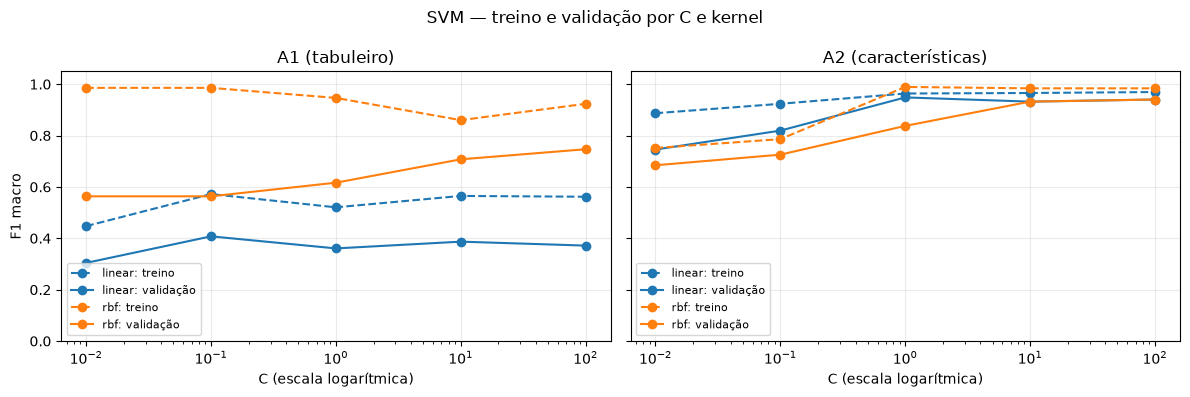

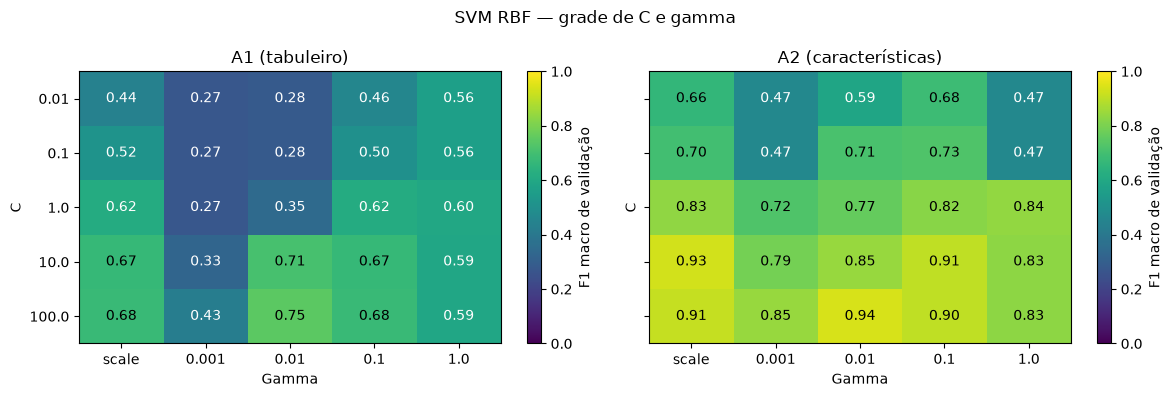

In [10]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for eixo, ab in zip(eixos, abordagens):
    linhas_ab = resultados[(resultados["codigo_abordagem"] == ab) & resultados["convergiu"]]
    for kernel, cor in [("linear", "tab:blue"), ("rbf", "tab:orange")]:
        linhas = linhas_ab[linhas_ab["kernel"] == kernel].sort_values(
            ["val_f1_macro", "val_acc", "n_vetores_suporte"],
            ascending=[False, False, True], kind="stable",
        ).drop_duplicates("C").sort_values("C")
        eixo.plot(linhas["C"], linhas["f1_treino"], marker="o", linestyle="--", color=cor,
                  label=f"{kernel}: treino")
        eixo.plot(linhas["C"], linhas["val_f1_macro"], marker="o", color=cor,
                  label=f"{kernel}: validação")
    eixo.set(title=abordagens[ab], xlabel="C (escala logarítmica)", xscale="log", ylim=(0, 1.05))
    eixo.grid(alpha=0.25)
    eixo.legend(fontsize=8)
eixos[0].set_ylabel("F1 macro")
fig.suptitle("SVM — treino e validação por C e kernel")
fig.tight_layout()
figuras["treino_validacao"] = fig
plt.show()

fig, eixos = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
ordem_gamma = [str(g) for g in lista_gamma]
for eixo, ab in zip(eixos, abordagens):
    linhas = resultados[(resultados["codigo_abordagem"] == ab) & (resultados["kernel"] == "rbf")]
    linhas = linhas[linhas["convergiu"]]
    matriz = linhas.pivot(index="C", columns="gamma", values="val_f1_macro").reindex(
        index=lista_C, columns=ordem_gamma,
    )
    imagem = eixo.imshow(matriz.to_numpy(), vmin=0, vmax=1, cmap="viridis", aspect="auto")
    eixo.set_xticks(range(len(ordem_gamma)), labels=ordem_gamma)
    eixo.set_yticks(range(len(lista_C)), labels=[str(C) for C in lista_C])
    eixo.set(title=abordagens[ab], xlabel="Gamma", ylabel="C")
    for i in range(len(lista_C)):
        for j in range(len(ordem_gamma)):
            valor = matriz.iloc[i, j]
            if pd.notna(valor):
                eixo.text(j, i, f"{valor:.2f}", ha="center", va="center",
                          color="white" if valor < 0.65 else "black")
    fig.colorbar(imagem, ax=eixo, label="F1 macro de validação")
fig.suptitle("SVM RBF — grade de C e gamma")
fig.tight_layout()
figuras["grade_rbf"] = fig
plt.show()

## 12. Avaliar as configurações selecionadas no teste e medir custo

Nesta etapa, o conjunto de teste avalia as duas configurações selecionadas pela validação.
Seus resultados não são utilizados para alterar a grade, os parâmetros ou a abordagem recomendada.

Medimos a média e o desvio padrão de 20 ajustes com os parâmetros fixados e de 20
previsões sobre o lote de 93 tabuleiros. As repetições têm finalidade de medição de tempo;
o modelo avaliado é o preservado durante a busca. Limitamos o paralelismo a uma thread
para tornar as medições mais controladas.

Os tempos incluem a padronização e o ajuste ou a previsão do classificador. A leitura dos
CSVs e a extração das características a partir de um tabuleiro não fazem parte dessas
medições, pois as duas representações já estão disponíveis nos arquivos preparados.
Assim, os valores descrevem o custo do processamento pelo modelo, não o tempo completo do front end.

`tempo_pred_ms` representa a previsão de **todo o lote**. O tempo por tabuleiro é a média
amortizada desse lote, obtida por divisão por 93; não corresponde à medição de uma chamada
individual. Hardware, versões, paralelismo e carga do computador influenciam os tempos.
A comparação entre algoritmos deve considerar essas condições de execução.

In [11]:
REPETICOES_TEMPO = 20
tabela = []
previsoes = {}

for ab, info in melhor.items():
    d = dados[ab]
    modelo = info["modelo"]
    print(f"Medindo custo e avaliando {abordagens[ab]}...", flush=True)
    duracoes_treino = []
    with threadpool_limits(limits=1):
        for _ in range(REPETICOES_TEMPO):
            novo_modelo = criar_modelo(**info["params"])
            inicio = time.perf_counter()
            avisos = ajustar_modelo(novo_modelo, d["X_train"], d["y_train"])
            duracoes_treino.append((time.perf_counter() - inicio) * 1000)
            if avisos:
                raise RuntimeError(f"Convergência mudou na medição de tempo: {avisos}")
        duracoes_pred = []
        for _ in range(REPETICOES_TEMPO):
            inicio = time.perf_counter()
            modelo.predict(d["X_test"])
            duracoes_pred.append((time.perf_counter() - inicio) * 1000)
        previsoes[ab] = modelo.predict(d["X_test"])

    m = metricas(d["y_test"], previsoes[ab])
    tabela.append({
        "codigo_abordagem": ab, "abordagem": abordagens[ab],
        "acuracia": m["acc"], "precision": m["precision"],
        "recall": m["recall"], "f1_macro": m["f1_macro"],
        "gap_treino_val": info["metricas_treino"]["f1_macro"] - info["metricas_validacao"]["f1_macro"],
        "tempo_treino_ms": float(np.mean(duracoes_treino)),
        "tempo_treino_desvio_ms": float(np.std(duracoes_treino)),
        "tempo_pred_ms": float(np.mean(duracoes_pred)),
        "tempo_pred_desvio_ms": float(np.std(duracoes_pred)),
        "tempo_pred_por_tabuleiro_ms": float(np.mean(duracoes_pred)) / len(d["X_test"]),
    })

tabela = pd.DataFrame(tabela)
tabela.round(4)

Medindo custo e avaliando A1 (tabuleiro)...
Medindo custo e avaliando A2 (características)...


,codigo_abordagem,abordagem,acuracia,precision,recall,f1_macro,gap_treino_val,tempo_treino_ms,tempo_treino_desvio_ms,tempo_pred_ms,tempo_pred_desvio_ms,tempo_pred_por_tabuleiro_ms
0,abordagem_1,A1 (tabuleiro),0.8387,0.8228,0.8750,0.8367,0.1768,22.3009,13.7225,1.3794,0.1089,0.0148
1,abordagem_2,A2 (características),0.9462,0.9625,0.9583,0.9575,0.0151,3.8535,0.1062,0.5120,0.0363,0.0055


## 13. Examinar métricas por classe

A média macro resume as quatro classes, mas o relatório por classe mostra quais estados
o classificador acerta e onde erra. **Suporte (support)** é a quantidade de exemplos reais daquela classe no conjunto avaliado.
No teste há somente três empates: acertar ou errar um muda bastante o recall dessa classe.
Não interpretamos uma pontuação alta nesse grupo como prova de desempenho estável.

In [12]:
relatorios = {}
for ab in abordagens:
    print("\n", abordagens[ab])
    print(classification_report(dados[ab]["y_test"], previsoes[ab], labels=CLASSES,
                                zero_division=0, digits=3))
    relatorios[ab] = classification_report(
        dados[ab]["y_test"], previsoes[ab], labels=CLASSES,
        zero_division=0, output_dict=True,
    )


 A1 (tabuleiro)
                  precision    recall  f1-score   support

        Tem jogo      0.857     0.600     0.706        30
Jogador X venceu      0.778     0.933     0.848        30
Jogador O venceu      0.906     0.967     0.935        30
          Empate      0.750     1.000     0.857         3

        accuracy                          0.839        93
       macro avg      0.823     0.875     0.837        93
    weighted avg      0.844     0.839     0.831        93


 A2 (características)
                  precision    recall  f1-score   support

        Tem jogo      1.000     0.833     0.909        30
Jogador X venceu      0.882     1.000     0.938        30
Jogador O venceu      0.968     1.000     0.984        30
          Empate      1.000     1.000     1.000         3

        accuracy                          0.946        93
       macro avg      0.963     0.958     0.958        93
    weighted avg      0.952     0.946     0.945        93



## 14. Visualizar os erros na matriz de confusão

As linhas são as classes reais e as colunas são as classes previstas. A diagonal contém
os acertos; os valores fora da diagonal mostram quais estados foram confundidos.
Por exemplo, uma vitória prevista como **Tem jogo** seria um erro relevante na interação.

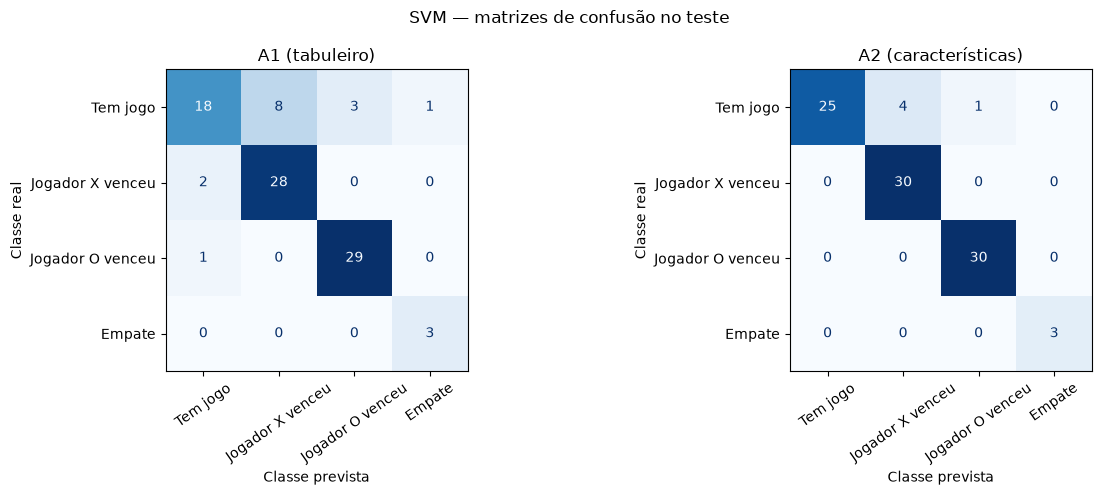

In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 5))
for eixo, ab in zip(eixos, abordagens):
    ConfusionMatrixDisplay.from_predictions(
        dados[ab]["y_test"], previsoes[ab], labels=CLASSES,
        display_labels=CLASSES, ax=eixo, colorbar=False, cmap="Blues", xticks_rotation=35,
    )
    eixo.set(title=abordagens[ab], xlabel="Classe prevista", ylabel="Classe real")
fig.suptitle("SVM — matrizes de confusão no teste")
fig.tight_layout()
figuras["matrizes_confusao"] = fig
plt.show()

## 15. Comparar desempenho e custo das abordagens

O primeiro gráfico compara as quatro métricas no teste. O segundo mostra os tempos de
treinamento e previsão em eixos separados, pois suas escalas são muito diferentes.
O número de características, o kernel e a quantidade de vetores de suporte influenciam
o custo; menos entradas não garantem automaticamente menor tempo de treino.

Esta comparação avalia as abordagens **com o SVM**. A escolha do algoritmo para a aplicação considera a comparação dos cinco classificadores.

A comparação consolidada e a escolha do SVM estão no [notebook de comparação](../comparacao/comparacao_classificadores.ipynb).


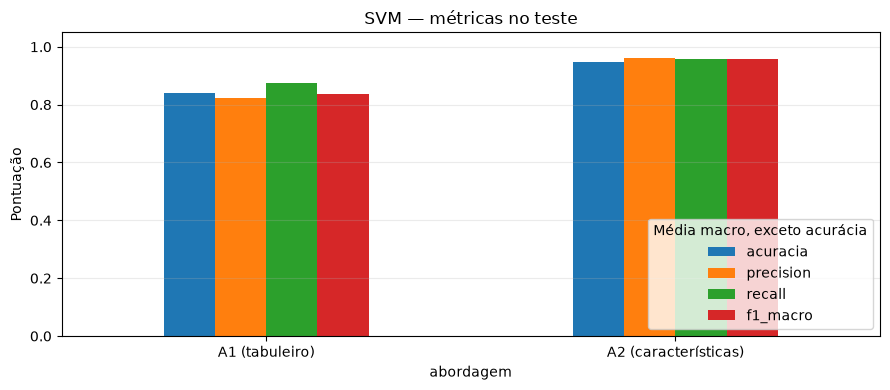

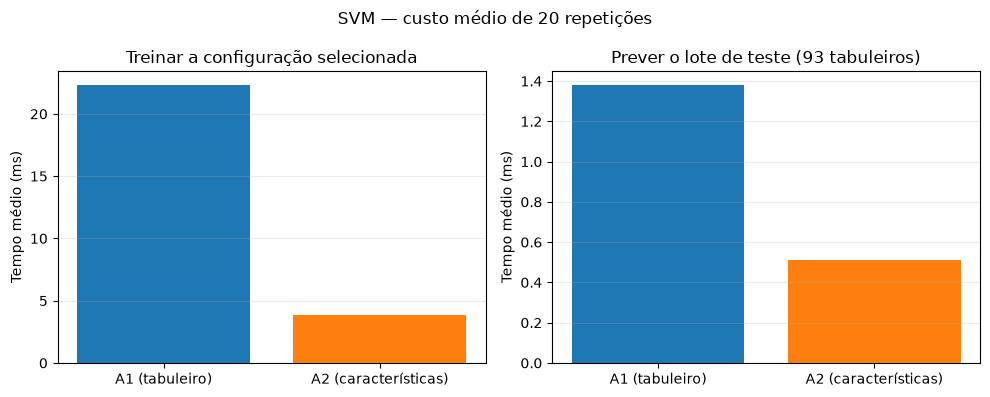

In [14]:
fig, eixo = plt.subplots(figsize=(9, 4))
tabela.set_index("abordagem")[["acuracia", "precision", "recall", "f1_macro"]].plot.bar(ax=eixo)
eixo.set(title="SVM — métricas no teste", ylabel="Pontuação", ylim=(0, 1.05))
eixo.tick_params(axis="x", rotation=0)
eixo.legend(title="Média macro, exceto acurácia", loc="lower right")
eixo.grid(axis="y", alpha=0.25)
fig.tight_layout()
figuras["metricas_teste"] = fig
plt.show()

fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
for eixo, coluna, titulo in zip(
    eixos, ["tempo_treino_ms", "tempo_pred_ms"],
    ["Treinar a configuração selecionada", "Prever o lote de teste (93 tabuleiros)"],
):
    eixo.bar(tabela["abordagem"], tabela[coluna], color=["tab:blue", "tab:orange"])
    eixo.set(title=titulo, ylabel="Tempo médio (ms)")
    eixo.grid(axis="y", alpha=0.25)
fig.suptitle(f"SVM — custo médio de {REPETICOES_TEMPO} repetições")
fig.tight_layout()
figuras["custo"] = fig
plt.show()

## 16. Documentar a conclusão do experimento

O texto abaixo usa os resultados desta execução para registrar parâmetros, métricas,
custo e limitações. A abordagem foi escolhida pela validação; os resultados de teste
avaliam essa escolha e não provocam novos ajustes.

Um F1 alto no teste é favorável, mas os poucos empates e a perda de informação da
abordagem 2 continuam limitando as conclusões. A escolha do algoritmo para a aplicação está documentada com os mesmos critérios de avaliação.

A comparação consolidada e a escolha do SVM estão no [notebook de comparação](../comparacao/comparacao_classificadores.ipynb).


In [15]:
conclusoes = []
for ab in abordagens:
    s = selecao.loc[selecao["codigo_abordagem"] == ab].iloc[0]
    t = tabela.loc[tabela["codigo_abordagem"] == ab].iloc[0]
    gamma_texto = f", gamma={s['gamma']} (efetivo: {s['gamma_efetivo']:.6g})" if s["kernel"] == "rbf" else ""
    conclusoes.append(
        f"**{abordagens[ab]}:** kernel **{s['kernel']}**, C={s['C']:g}{gamma_texto}, "
        f"{s['n_vetores_suporte']} vetores de suporte e {s['n_features']} entradas. "
        f"F1 macro: treino {s['f1_treino']:.3f}, validação {s['val_f1_macro']:.3f} "
        f"e teste {t['f1_macro']:.3f}; acurácia no teste {t['acuracia']:.1%}. "
        f"Diferença treino–validação: {s['gap_treino_val']:.3f}. "
        f"Treino médio: {t['tempo_treino_ms']:.2f} ms; previsão do lote: {t['tempo_pred_ms']:.3f} ms."
    )

vencedora = selecao.loc[selecao["codigo_abordagem"] == ab_escolhida].iloc[0]
mais_rapida_treino = tabela.loc[tabela["tempo_treino_ms"].idxmin(), "abordagem"]
mais_rapida_pred = tabela.loc[tabela["tempo_pred_ms"].idxmin(), "abordagem"]
texto_conclusao = (
    "\n\n".join(conclusoes)
    + f"\n\n**Recomendação para o SVM:** {abordagens[ab_escolhida]}, escolhida antes do teste "
      f"pelo F1 macro de validação ({vencedora['val_f1_macro']:.3f}) e pelos critérios de desempate. "
      f"Nesta medição, {mais_rapida_treino} teve menor tempo médio de treino e "
      f"{mais_rapida_pred} teve menor tempo médio de previsão. Os tempos podem oscilar entre execuções."
)
maior_gap = selecao.loc[selecao["gap_treino_val"].idxmax()]
texto_conclusao += (
    f"\n\n**Generalização:** a maior diferença entre treino e validação foi "
    f"{maior_gap['gap_treino_val']:.3f}, em {maior_gap['abordagem']}. "
    "A diferença deve ser interpretada junto com os resultados por classe; "
    "ela não demonstra, sozinha, presença ou ausência de overfitting."
)
for ab in abordagens:
    empates = relatorios[ab]["Empate"]
    quantidade = int(round(empates["recall"] * empates["support"]))
    texto_conclusao += f" {abordagens[ab]} reconheceu {quantidade} dos {int(empates['support'])} empates do teste."

texto_conclusao += (
    "\n\n**Limitações:** somente dois empates na validação e três no teste; "
    "reamostragem não cria novos empates; possíveis simetrias entre divisões; "
    "entradas iguais com rótulos diferentes na abordagem 2; busca finita. "
    "São resultados desta amostra, sem garantia de desempenho em qualquer partida. "
    "A avaliação durante partidas com usuários deve ser registrada separadamente no front end\ne apresentada no relatório, pois mede uma situação de uso diferente do teste reservado."
)
display(Markdown(texto_conclusao))

**A1 (tabuleiro):** kernel **rbf**, C=100, gamma=0.01 (efetivo: 0.01), 317 vetores de suporte e 9 entradas. F1 macro: treino 0.924, validação 0.747 e teste 0.837; acurácia no teste 83.9%. Diferença treino–validação: 0.177. Treino médio: 22.30 ms; previsão do lote: 1.379 ms.

**A2 (características):** kernel **linear**, C=1, 144 vetores de suporte e 15 entradas. F1 macro: treino 0.964, validação 0.949 e teste 0.958; acurácia no teste 94.6%. Diferença treino–validação: 0.015. Treino médio: 3.85 ms; previsão do lote: 0.512 ms.

**Recomendação para o SVM:** A2 (características), escolhida antes do teste pelo F1 macro de validação (0.949) e pelos critérios de desempate. Nesta medição, A2 (características) teve menor tempo médio de treino e A2 (características) teve menor tempo médio de previsão. Os tempos podem oscilar entre execuções.

**Generalização:** a maior diferença entre treino e validação foi 0.177, em A1 (tabuleiro). A diferença deve ser interpretada junto com os resultados por classe; ela não demonstra, sozinha, presença ou ausência de overfitting. A1 (tabuleiro) reconheceu 3 dos 3 empates do teste. A2 (características) reconheceu 3 dos 3 empates do teste.

**Limitações:** somente dois empates na validação e três no teste; reamostragem não cria novos empates; possíveis simetrias entre divisões; entradas iguais com rótulos diferentes na abordagem 2; busca finita. São resultados desta amostra, sem garantia de desempenho em qualquer partida. A avaliação durante partidas com usuários deve ser registrada separadamente no front end
e apresentada no relatório, pois mede uma situação de uso diferente do teste reservado.

## 17. Salvar os resultados e o classificador com seu pré-processamento

Salvamos a busca, as configurações selecionadas, as métricas, as previsões individuais,
os relatórios por classe e os gráficos. O resumo JSON registra parâmetros, versões,
colunas esperadas e hashes dos CSVs, permitindo identificar os dados deste experimento.
A conclusão fica também em Markdown.

`modelo_svm.joblib` contém o **Pipeline completo** da abordagem escolhida pela validação,
incluindo o padronizador ajustado no treino. As futuras entradas devem ter as mesmas
colunas, na mesma ordem e representação. `id_tabuleiro` e `estado` não são entradas.
O arquivo exporta o modelo já avaliado; não há novo treino com validação ou teste.

In [16]:
PASTA_RESULTADOS.mkdir(parents=True, exist_ok=True)
resultados.to_csv(PASTA_RESULTADOS / "busca_validacao.csv", index=False)
selecao.to_csv(PASTA_RESULTADOS / "configuracoes_selecionadas.csv", index=False)
tabela.to_csv(PASTA_RESULTADOS / "metricas_teste.csv", index=False)

linhas_predicoes = []
for ab in abordagens:
    linhas_predicoes.append(pd.DataFrame({
        "abordagem": ab, "id_tabuleiro": dados[ab]["ids_test"].to_numpy(),
        "estado_real": dados[ab]["y_test"], "estado_previsto": previsoes[ab],
        "acertou": dados[ab]["y_test"] == previsoes[ab],
    }))
pd.concat(linhas_predicoes, ignore_index=True).to_csv(PASTA_RESULTADOS / "previsoes_teste.csv", index=False)
(PASTA_RESULTADOS / "relatorios_por_classe.json").write_text(
    json.dumps(relatorios, ensure_ascii=False, indent=2), encoding="utf-8",
)

svc_exportado = melhor[ab_escolhida]["modelo"].named_steps["svc"]
resumo = {
    "algoritmo": "SVC (SVM)", "semente_preparacao_dados": SEED,
    "ajuste_deterministico_sem_calibracao": True,
    "versoes": versoes, "plataforma": platform.platform(), "threads_blas": 1,
    "classes": CLASSES,
    "criterio_selecao_configuracao": "F1 macro de validação; acurácia; kernel linear; menor C; menos vetores de suporte",
    "criterio_selecao_abordagem": "F1 macro de validação; acurácia; menos vetores de suporte; menos características",
    "parametros_fixos": PARAMETROS_FIXOS,
    "grade": grade, "configuracoes_testadas": len(resultados),
    "avisos_convergencia": int((~resultados["convergiu"]).sum()),
    "abordagem_escolhida_pela_validacao": ab_escolhida,
    "configuracoes_selecionadas": {ab: info["params"] for ab, info in melhor.items()},
    "features_modelo_exportado": list(dados[ab_escolhida]["X_train"].columns),
    "ordem_classes_modelo": list(map(str, svc_exportado.classes_)),
    "vetores_suporte_por_classe": dict(zip(map(str, svc_exportado.classes_), map(int, svc_exportado.n_support_))),
    "repeticoes_tempo": REPETICOES_TEMPO,
    "csvs_entrada_sha256": {
        str(caminho.relative_to(RAIZ)): hashlib.sha256(caminho.read_bytes()).hexdigest()
        for caminho in arquivos_entrada
    },
}
(PASTA_RESULTADOS / "resumo_experimento.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2), encoding="utf-8",
)
(PASTA_RESULTADOS / "conclusao.md").write_text(texto_conclusao + "\n", encoding="utf-8")
for nome, figura in figuras.items():
    figura.savefig(PASTA_RESULTADOS / f"{nome}.png", dpi=150, bbox_inches="tight")
joblib.dump(melhor[ab_escolhida]["modelo"], PASTA_RESULTADOS / "modelo_svm.joblib")

print("Arquivos salvos em:", PASTA_RESULTADOS.relative_to(RAIZ))
for caminho in sorted(PASTA_RESULTADOS.iterdir()):
    print(" -", caminho.name)

Arquivos salvos em: dataset/processado/svm/resultados
 - busca_validacao.csv
 - conclusao.md
 - configuracoes_selecionadas.csv
 - custo.png
 - grade_rbf.png
 - matrizes_confusao.png
 - metricas_teste.csv
 - metricas_teste.png
 - modelo_svm.joblib
 - previsoes_teste.csv
 - relatorios_por_classe.json
 - resumo_experimento.json
 - treino_validacao.png
